# Figure 5 — Joint Correlated Random Effects Model

Visualizes the joint choice + vigor model with LKJ-correlated random effects.

**Panels:**
- **A**: ELBO convergence (joint vs choice-only)
- **B**: Forest plot of posterior correlations from LKJ prior (omega samples)
- **C**: Scatter of beta_joint vs delta_joint
- **D**: Scatter of k_joint vs delta_joint
- **E**: Parameter validation — delta (joint) vs delta (OLS)

In [1]:
import sys
sys.path.insert(0, '/workspace')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr, gaussian_kde
from pathlib import Path

from scripts.plotting.plotter import Colors, set_plot_style, style_axis

set_plot_style()

# Paths
STAT_DIR = Path('/workspace/results/stats')
FIG_DIR  = Path('/workspace/results/figs/paper')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Imports and style configured.')

Imports and style configured.


In [2]:
# ── Load all data ─────────────────────────────────────────────────────────────
elbo_df   = pd.read_csv(STAT_DIR / 'joint_correlated_elbo_history.csv')
omega_df  = pd.read_csv(STAT_DIR / 'joint_correlated_omega_samples.csv')
corr_df   = pd.read_csv(STAT_DIR / 'joint_correlated_correlations.csv')
subj_df   = pd.read_csv(STAT_DIR / 'joint_correlated_subjects.csv')
pop_df    = pd.read_csv(STAT_DIR / 'joint_correlated_population.csv')

# Load INDEPENDENTLY estimated parameters for scatter validation
# β from L3_add (choice-only), δ from OLS (per-subject regression)
# This avoids inflation from the correlated prior structure
separate_df = pd.read_csv(STAT_DIR / 'unified_3param_clean.csv')
merged_val = separate_df.merge(subj_df[['subj', 'delta_ols']], on='subj')

print(f'ELBO history:    {len(elbo_df)} steps')
print(f'Omega samples:   {len(omega_df)} draws x {omega_df.shape[1]} pairs')
print(f'Correlations:    {len(corr_df)} pairs')
print(f'Subjects:        {len(subj_df)} subjects')
print(f'Validation set:  {len(merged_val)} subjects (separate β × OLS δ)')
print()
print('Correlation summary:')
print(corr_df[['param_1', 'param_2', 'rho_mean', 'rho_2.5', 'rho_97.5', 'P_positive']].to_string(index=False))

ELBO history:    30000 steps
Omega samples:   4000 draws x 6 pairs
Correlations:    6 pairs
Subjects:        293 subjects
Validation set:  293 subjects (separate β × OLS δ)

Correlation summary:
 param_1  param_2  rho_mean  rho_2.5  rho_97.5  P_positive
   log_k log_beta   -0.1826  -0.2987   -0.0663      0.0018
   log_k    alpha    0.3829   0.3193    0.4426      1.0000
   log_k    delta   -0.7301  -0.7887   -0.6597      0.0000
log_beta    alpha   -0.3309  -0.3911   -0.2677      0.0000
log_beta    delta    0.7537   0.6714    0.8265      1.0000
   alpha    delta   -0.2290  -0.3177   -0.1262      0.0002


/workspace/scripts/plotting/plotter.py:99: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(ygrid, axis='y', color=Colors.GREY, alpha=0.55)


Saved: /workspace/results/figs/paper/fig5_joint_model.pdf
Saved: /workspace/results/figs/paper/fig5_joint_model.png


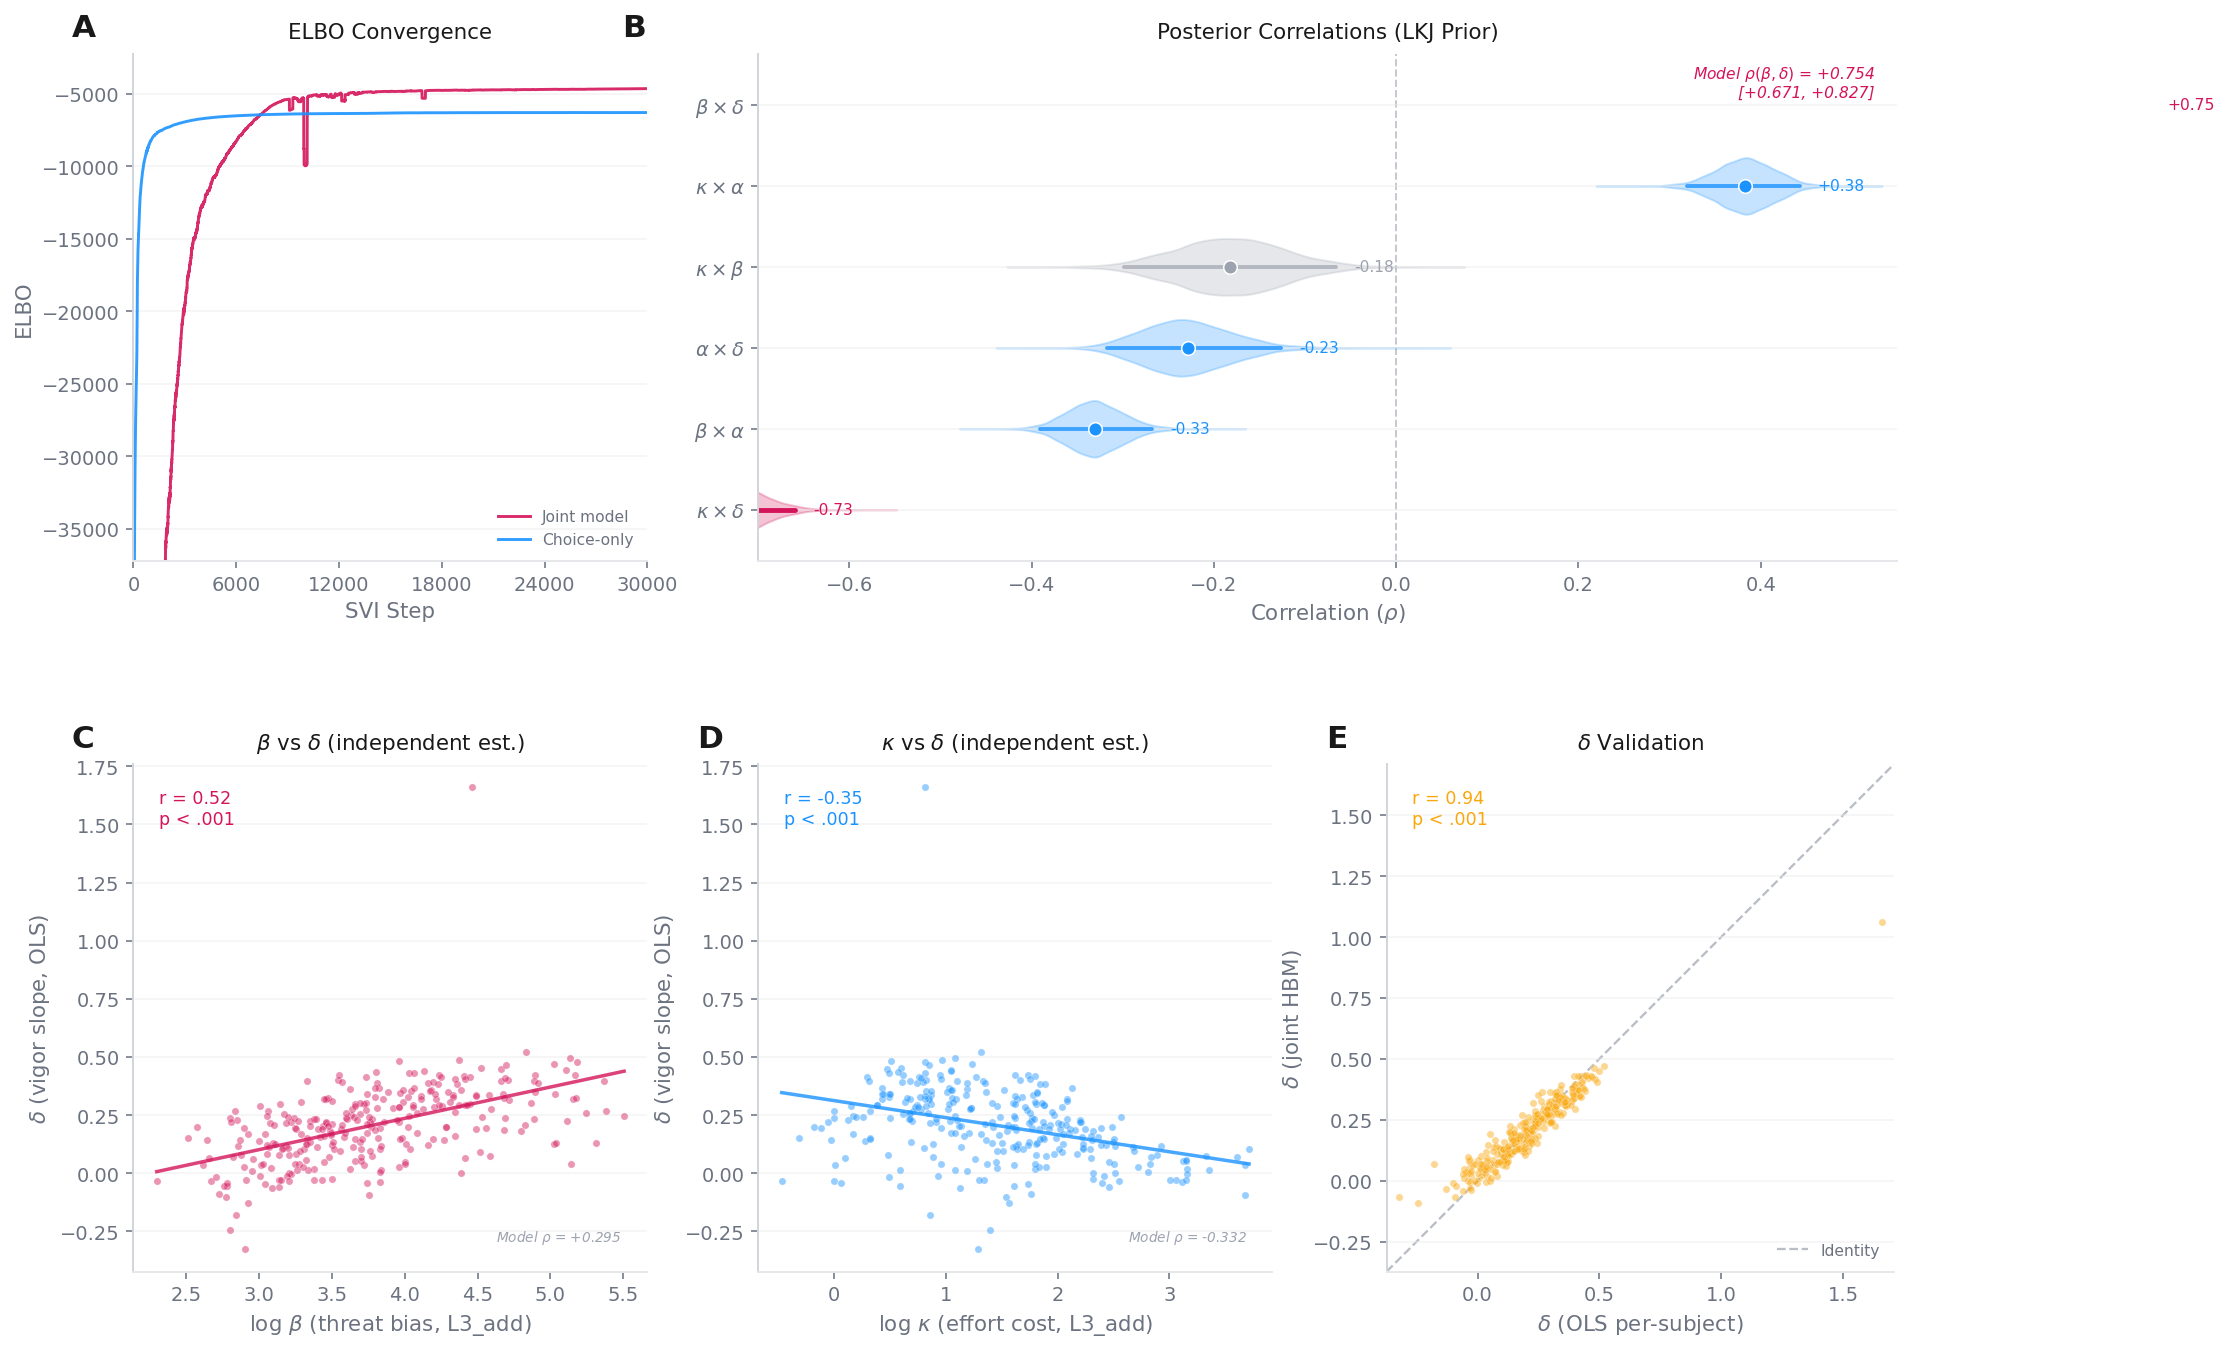

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 5 — Multi-panel layout
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(14, 10), facecolor='white')
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.40, wspace=0.55,
                       left=0.07, right=0.97, top=0.94, bottom=0.07)

# Panel positions
ax_A = fig.add_subplot(gs[0, 0:2])   # ELBO convergence
ax_B = fig.add_subplot(gs[0, 2:6])   # Forest plot (wider)
ax_C = fig.add_subplot(gs[1, 0:2])   # beta vs delta (INDEPENDENT estimates)
ax_D = fig.add_subplot(gs[1, 2:4])   # k vs delta (INDEPENDENT estimates)
ax_E = fig.add_subplot(gs[1, 4:6])   # delta validation

# ── Panel labels ──────────────────────────────────────────────────────────────
for ax, label in zip([ax_A, ax_B, ax_C, ax_D, ax_E], list('ABCDE')):
    ax.text(-0.12, 1.08, label, transform=ax.transAxes,
            fontsize=16, fontweight='bold', color=Colors.DARK_GREY, va='top')

# ==============================================================================
# Panel A: ELBO convergence
# ==============================================================================
window = 200
elbo_joint_smooth  = elbo_df['elbo_joint'].rolling(window, min_periods=1).mean()
elbo_choice_smooth = elbo_df['elbo_choice'].rolling(window, min_periods=1).mean()
steps = elbo_df['step'].values

ax_A.plot(steps, elbo_joint_smooth,  color=Colors.RUBY1, linewidth=1.5,
          label='Joint model', alpha=0.9)
ax_A.plot(steps, elbo_choice_smooth, color=Colors.CERULEAN2, linewidth=1.5,
          label='Choice-only', alpha=0.9)

converged_start = 2000
mask = steps >= converged_start
y_min = min(elbo_joint_smooth[mask].min(), elbo_choice_smooth[mask].min())
y_max = max(elbo_joint_smooth[mask].max(), elbo_choice_smooth[mask].max())
y_pad = (y_max - y_min) * 0.08
ax_A.set_ylim(y_min - y_pad, y_max + y_pad)
ax_A.set_xlim(0, steps.max())

ax_A.legend(fontsize=8, frameon=False, loc='lower right',
            labelcolor=Colors.INK)
ax_A.set_title('ELBO Convergence', fontsize=11, color=Colors.DARK_GREY, pad=8)
style_axis(ax_A, xlabel='SVI Step', ylabel='ELBO')
ax_A.xaxis.set_major_locator(MaxNLocator(5))

# ==============================================================================
# Panel B: Forest plot of LKJ posterior correlations
# ==============================================================================
pair_cols = omega_df.columns.tolist()
label_map = {
    'rho_log_k_log_beta': r'$\kappa \times \beta$',
    'rho_log_k_alpha':    r'$\kappa \times \alpha$',
    'rho_log_k_delta':    r'$\kappa \times \delta$',
    'rho_log_beta_alpha': r'$\beta \times \alpha$',
    'rho_log_beta_delta': r'$\beta \times \delta$',
    'rho_alpha_delta':    r'$\alpha \times \delta$',
}

key_pairs = {'rho_log_beta_delta', 'rho_log_k_delta'}
highlight_pairs = {'rho_log_k_alpha', 'rho_log_beta_alpha', 'rho_alpha_delta'}

pair_means = {col: omega_df[col].mean() for col in pair_cols}
pair_order = sorted(pair_cols, key=lambda c: pair_means[c])

ax_B.axvline(0, color=Colors.SLATE, linewidth=1, linestyle='--', alpha=0.6, zorder=0)

for i, col in enumerate(pair_order):
    samples = omega_df[col].values
    mean_val = np.mean(samples)
    ci_lo = np.percentile(samples, 2.5)
    ci_hi = np.percentile(samples, 97.5)

    if col in key_pairs:
        color = Colors.RUBY1
        alpha = 1.0
        lw = 2.5
    elif col in highlight_pairs:
        color = Colors.CERULEAN2
        alpha = 0.8
        lw = 2.0
    else:
        color = Colors.SLATE
        alpha = 0.7
        lw = 2.0

    try:
        kde = gaussian_kde(samples)
        x_grid = np.linspace(samples.min() - 0.05, samples.max() + 0.05, 300)
        density = kde(x_grid)
        density_norm = density / density.max() * 0.35
        ax_B.fill_between(x_grid, i - density_norm, i + density_norm,
                          color=color, alpha=0.25, zorder=1)
    except Exception:
        pass

    ax_B.plot([ci_lo, ci_hi], [i, i], color=color, linewidth=lw,
              alpha=alpha, solid_capstyle='round', zorder=2)
    ax_B.plot(mean_val, i, 'o', color=color, markersize=7, zorder=3,
              markeredgecolor='white', markeredgewidth=0.8)

    ax_B.text(ci_hi + 0.02, i, f'{mean_val:+.2f}',
              fontsize=8, color=color, va='center', ha='left')

ax_B.set_yticks(range(len(pair_order)))
ax_B.set_yticklabels([label_map.get(c, c) for c in pair_order], fontsize=10)
ax_B.set_title('Posterior Correlations (LKJ Prior)', fontsize=11,
               color=Colors.DARK_GREY, pad=8)
style_axis(ax_B, xlabel=r'Correlation ($\rho$)', ygrid=False)
ax_B.set_xlim(-0.7, 0.55)

# Add model rho annotation for key pair
bd_row = corr_df[(corr_df['param_1']=='log_beta') & (corr_df['param_2']=='delta')]
if len(bd_row) > 0:
    rho_val = bd_row.iloc[0]['rho_mean']
    ci_lo_bd = bd_row.iloc[0]['rho_2.5']
    ci_hi_bd = bd_row.iloc[0]['rho_97.5']
    ax_B.text(0.98, 0.98, f'Model $\\rho(\\beta, \\delta)$ = {rho_val:+.3f}\n[{ci_lo_bd:+.3f}, {ci_hi_bd:+.3f}]',
              transform=ax_B.transAxes, fontsize=8, color=Colors.RUBY1,
              va='top', ha='right', style='italic')

# ==============================================================================
# Panel C: β (L3_add, separate) vs δ (OLS) — INDEPENDENT ESTIMATES
# ==============================================================================
x_c = np.log(merged_val['beta'].values + 1e-6)
y_c = merged_val['delta_ols'].values
r_c, p_c = pearsonr(x_c, y_c)

ax_C.scatter(x_c, y_c, s=14, alpha=0.45, color=Colors.RUBY1,
             edgecolors='white', linewidths=0.3, zorder=2)

m, b = np.polyfit(x_c, y_c, 1)
x_line = np.linspace(x_c.min(), x_c.max(), 100)
ax_C.plot(x_line, m * x_line + b, color=Colors.RUBY1, linewidth=1.8,
          alpha=0.8, zorder=3)

sig_str = 'p < .001' if p_c < 0.001 else f'p = {p_c:.3f}'
ax_C.text(0.05, 0.95, f'r = {r_c:.2f}\n{sig_str}',
          transform=ax_C.transAxes, fontsize=9, color=Colors.RUBY1,
          va='top', ha='left')
# Annotate model rho
ax_C.text(0.95, 0.05, f'Model $\\rho$ = +0.295',
          transform=ax_C.transAxes, fontsize=7, color=Colors.SLATE,
          va='bottom', ha='right', style='italic')
ax_C.set_title(r'$\beta$ vs $\delta$ (independent est.)', fontsize=11,
               color=Colors.DARK_GREY, pad=8)
style_axis(ax_C, xlabel=r'log $\beta$ (threat bias, L3_add)', ylabel=r'$\delta$ (vigor slope, OLS)')

# ==============================================================================
# Panel D: k (L3_add, separate) vs δ (OLS) — INDEPENDENT ESTIMATES
# ==============================================================================
x_d = np.log(merged_val['k'].values + 1e-6)
y_d = merged_val['delta_ols'].values
r_d, p_d = pearsonr(x_d, y_d)

ax_D.scatter(x_d, y_d, s=14, alpha=0.45, color=Colors.CERULEAN2,
             edgecolors='white', linewidths=0.3, zorder=2)

m2, b2 = np.polyfit(x_d, y_d, 1)
x_line2 = np.linspace(x_d.min(), x_d.max(), 100)
ax_D.plot(x_line2, m2 * x_line2 + b2, color=Colors.CERULEAN2, linewidth=1.8,
          alpha=0.8, zorder=3)

sig_str2 = 'p < .001' if p_d < 0.001 else f'p = {p_d:.3f}'
ax_D.text(0.05, 0.95, f'r = {r_d:.2f}\n{sig_str2}',
          transform=ax_D.transAxes, fontsize=9, color=Colors.CERULEAN2,
          va='top', ha='left')
ax_D.text(0.95, 0.05, f'Model $\\rho$ = -0.332',
          transform=ax_D.transAxes, fontsize=7, color=Colors.SLATE,
          va='bottom', ha='right', style='italic')
ax_D.set_title(r'$\kappa$ vs $\delta$ (independent est.)', fontsize=11,
               color=Colors.DARK_GREY, pad=8)
style_axis(ax_D, xlabel=r'log $\kappa$ (effort cost, L3_add)', ylabel=r'$\delta$ (vigor slope, OLS)')

# ==============================================================================
# Panel E: Parameter validation — delta (joint HBM) vs delta (OLS)
# ==============================================================================
delta_joint = subj_df['delta'].values
delta_ols   = subj_df['delta_ols'].values
r_e, p_e = pearsonr(delta_joint, delta_ols)

ax_E.scatter(delta_ols, delta_joint, s=14, alpha=0.45, color=Colors.PERSIMMON3,
             edgecolors='white', linewidths=0.3, zorder=2)

lims = [min(delta_ols.min(), delta_joint.min()) - 0.05,
        max(delta_ols.max(), delta_joint.max()) + 0.05]
ax_E.plot(lims, lims, '--', color=Colors.SLATE, linewidth=1.2, alpha=0.7,
          zorder=1, label='Identity')

sig_str3 = 'p < .001' if p_e < 0.001 else f'p = {p_e:.3f}'
ax_E.text(0.05, 0.95, f'r = {r_e:.2f}\n{sig_str3}',
          transform=ax_E.transAxes, fontsize=9, color=Colors.PERSIMMON3,
          va='top', ha='left')
ax_E.set_title(r'$\delta$ Validation', fontsize=11,
               color=Colors.DARK_GREY, pad=8)
style_axis(ax_E, xlabel=r'$\delta$ (OLS per-subject)', ylabel=r'$\delta$ (joint HBM)')
ax_E.legend(fontsize=8, frameon=False, loc='lower right', labelcolor=Colors.INK)
ax_E.set_xlim(lims)
ax_E.set_ylim(lims)
ax_E.set_aspect('equal', adjustable='box')

# ── Save ──────────────────────────────────────────────────────────────────────
fig.savefig(FIG_DIR / 'fig5_joint_model.pdf', bbox_inches='tight', facecolor='white')
fig.savefig(FIG_DIR / 'fig5_joint_model.png', bbox_inches='tight', facecolor='white', dpi=300)
print(f'Saved: {FIG_DIR}/fig5_joint_model.pdf')
print(f'Saved: {FIG_DIR}/fig5_joint_model.png')
plt.show()